# Benchmark Plotting Notebook

This notebook parses a Google Benchmark-style output file that may contain non-CSV header text before the CSV header line, then plots:

- Mean **real_time** vs **N** with stddev error bars
- Mean **items_per_second** vs **N** with stddev error bars (if present)

It prefers `_mean` and `_stddev` rows when available; otherwise it computes stats from raw repeated runs.


In [14]:
from __future__ import annotations

import io
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [18]:
INPUT_PATH = "data/bench_450dc0d.csv"   # path to benchmark output file
BENCH_BASE = "BM_ParticlesUpdate"  # benchmark base name to plot

CSV_HEADER = "name,iterations,real_time,cpu_time,time_unit,bytes_per_second,items_per_second,label,error_occurred,error_message"

_name_re = re.compile(r"^(?P<base>.+?)/(?P<n>\d+)(?P<suffix>_(mean|median|stddev|cv))?$")

def extract_csv_block(text: str) -> str:
    """Return the CSV portion starting at the known header line."""
    idx = text.find(CSV_HEADER)
    if idx < 0:
        raise ValueError("Could not find CSV header line in the input.")
    return text[idx:]

def split_name(name: str):
    """Parse 'BM_ParticlesUpdate/200_mean' -> (base, n, suffix)."""
    m = _name_re.match(str(name).strip().strip('"'))
    if not m:
        return None, None, None
    base = m.group("base")
    n = int(m.group("n"))
    suffix = m.group("suffix")  # None, '_mean', '_stddev', ...
    return base, n, suffix

def to_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def build_stats(df: pd.DataFrame, base_filter: str) -> pd.DataFrame:
    """Build stats table: n, real_time_mean, real_time_std, ips_mean, ips_std."""
    parsed = df["name"].astype(str).apply(split_name)
    df = df.copy()
    df["base"] = parsed.apply(lambda t: t[0])
    df["n"] = parsed.apply(lambda t: t[1])
    df["suffix"] = parsed.apply(lambda t: t[2])

    df = df[df["base"] == base_filter].copy()
    df = to_numeric(df, ["real_time", "items_per_second"])

    time_unit_vals = df["time_unit"].dropna().astype(str).unique()
    time_unit = time_unit_vals[0] if len(time_unit_vals) else "time_unit"

    have_mean = (df["suffix"] == "_mean").any()
    have_std = (df["suffix"] == "_stddev").any()

    rows = []
    for n, g in df.groupby("n"):
        entry = {"n": int(n), "time_unit": time_unit}

        if have_mean:
            mean_row = g[g["suffix"] == "_mean"]
            entry["real_time_mean"] = float(mean_row["real_time"].iloc[0]) if len(mean_row) else np.nan
            entry["ips_mean"] = float(mean_row["items_per_second"].iloc[0]) if len(mean_row) else np.nan
        else:
            raw = g[g["suffix"].isna()]
            entry["real_time_mean"] = float(raw["real_time"].mean()) if len(raw) else np.nan
            entry["ips_mean"] = float(raw["items_per_second"].mean()) if len(raw) else np.nan

        if have_std:
            std_row = g[g["suffix"] == "_stddev"]
            entry["real_time_std"] = float(std_row["real_time"].iloc[0]) if len(std_row) else np.nan
            entry["ips_std"] = float(std_row["items_per_second"].iloc[0]) if len(std_row) else np.nan
        else:
            raw = g[g["suffix"].isna()]
            entry["real_time_std"] = float(raw["real_time"].std(ddof=1)) if len(raw) > 1 else 0.0
            entry["ips_std"] = float(raw["items_per_second"].std(ddof=1)) if len(raw) > 1 else 0.0

        rows.append(entry)

    return pd.DataFrame(rows).sort_values("n").reset_index(drop=True)

def plot_stats(stats: pd.DataFrame, base_filter: str, log_axes: bool = True) -> None:
    n = stats["n"].to_numpy()

    # Plot 1: time
    plt.figure()
    plt.errorbar(n, stats["real_time_mean"], yerr=stats["real_time_std"], marker="o", capsize=4)
    if log_axes:
        plt.xscale("log")
        plt.yscale("log")
    unit = stats["time_unit"].iloc[0] if "time_unit" in stats.columns and len(stats) else "time"
    plt.xlabel("number of particles")
    plt.ylabel(f"real_time mean ({unit})")
    plt.title(f"{base_filter}: real_time vs number of particles")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()

    # Plot 2: items/s
    if stats["ips_mean"].notna().any():
        plt.figure()
        plt.errorbar(n, stats["ips_mean"], yerr=stats["ips_std"], marker="o", capsize=4)
        if log_axes:
            plt.xscale("log")
            plt.yscale("log")
        plt.xlabel("number of particles")
        plt.ylabel("items_per_second mean")
        plt.title(f"{base_filter}: throughput vs number of particles")
        plt.grid(True, which="both", linestyle="--", linewidth=0.5)
        plt.show()


In [16]:
# --- Load and parse ---
text = Path(INPUT_PATH).read_text(encoding="utf-8", errors="replace")
csv_text = extract_csv_block(text)
df = pd.read_csv(io.StringIO(csv_text))

stats = build_stats(df, base_filter=BENCH_BASE)
stats


,n,time_unit,real_time_mean,ips_mean,real_time_std,ips_std
0,200,ms,1.13651,178373.0,0.047628,4872.730
1,500,ms,7.02539,71564.4,0.289701,2847.690
2,1000,ms,29.36280,34649.9,1.765920,2495.670
3,2000,ms,107.16300,18763.8,3.210480,566.667


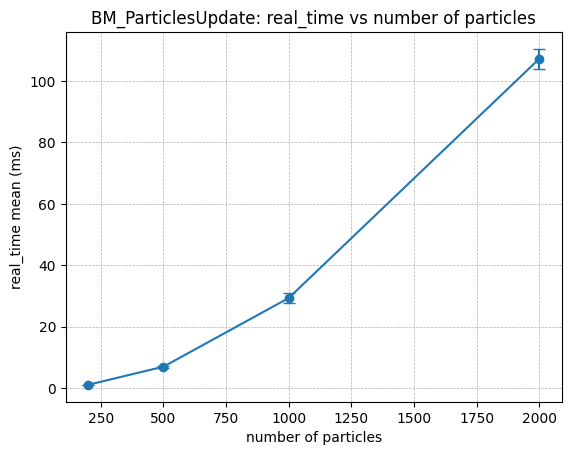

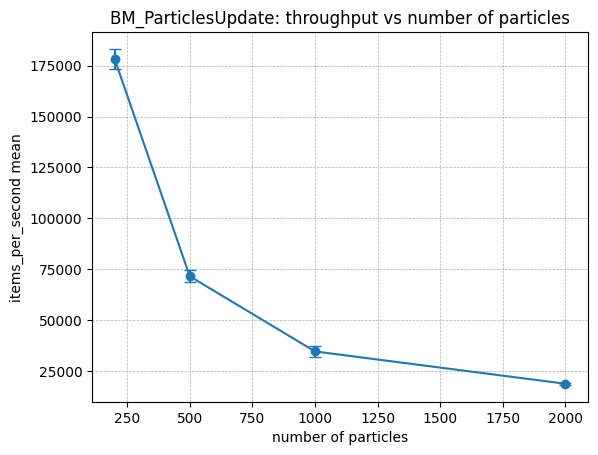

In [19]:
# --- Plot ---
plot_stats(stats, base_filter=BENCH_BASE, log_axes=False)
